# NYPD Arrest Analysis - January 2025
**Created by: Sarah Sellami**

**Course:** CIS 2300  
**Project:** Analyzing Our City Life with Open Data  
**Dataset:** NYPD Arrests Historic Dataset  

In [41]:
# Load required libraries
from sodapy import Socrata # Import the library to talk to the NYC Data API
import pandas as pd # Import pandas for data tables
import matplotlib.pyplot as plt #matplotlib for visualization
from dotenv import load_dotenv
import os

## Data Collection

This section loads the dataet from NYC Open Data.

We connected to the NYC Open Data API using Socrata and retrieved arrest records from January 2025. We used filters and selected specific columns to make the dataet easier to manage and analyze.

In [43]:
# Load API token
load_dotenv()
MY_APP_TOKEN = os.getenv("NYC_DATA_TOKEN")

# Connect to NYC Open Data
client = Socrata("data.cityofnewyork.us", MY_APP_TOKEN)

# Load NYC arrest data
results = client.get(
    "8h9b-rp9u",
    limit=24000,
    select="ARREST_DATE, PD_DESC, OFNS_DESC, LAW_CODE, ARREST_BORO, ARREST_PRECINCT, AGE_GROUP, PERP_SEX",
    where="arrest_date >= '2025-01-01T00:00:00' AND arrest_date <= '2025-01-31T23:59:59'"
)

# Convert to DataFrame
df = pd.DataFrame.from_records(results)
# Save CSV copy
df.to_csv('NYPDArrestsData.csv', index=False)
# Preview the dataet
df.head()

,ARREST_DATE,PD_DESC,OFNS_DESC,LAW_CODE,ARREST_BORO,ARREST_PRECINCT,AGE_GROUP,PERP_SEX
0,2025-01-01T00:00:00.000,"STOLEN PROPERTY 2,1,POSSESSION",POSSESSION OF STOLEN PROPERTY,PL 1654502,K,70,(null),(null)
1,2025-01-01T00:00:00.000,"SEXUAL ABUSE 3,2",SEX CRIMES,PL 1305201,Q,101,(null),(null)
2,2025-01-01T00:00:00.000,"LARCENY,GRAND OF AUTO",GRAND LARCENY OF MOTOR VEHICLE,PL 1553008,Q,107,(null),(null)
3,2025-01-01T00:00:00.000,"TRAFFIC,UNCLASSIFIED MISDEMEAN",VEHICLE AND TRAFFIC LAWS,VTL0511001,B,45,(null),(null)
4,2025-01-01T00:00:00.000,"THEFT OF SERVICES, UNCLASSIFIE",OTHER OFFENSES RELATED TO THEFT,PL 1651503,B,41,(null),(null)


We used the Socrata library to connect to the NYC Open Data portal. We initialized the baseUrl and our MY_APP_TOKEN to request the dataet. We set a limit of 24,000 rows and selected specific columns like arrest date, age group, and borough from January 2025. 

In [44]:
# Clean column names and dates
df = df.rename(columns={
    'ARREST_DATE': 'Arrest_Date',
    'PD_DESC': 'Offense_Detail',
    'OFNS_DESC': 'Offense_Category',
    'LAW_CODE': 'NY_Law_Code',
    'ARREST_BORO': 'Borough',
    'ARREST_PRECINCT': 'Precinct',
    'AGE_GROUP': 'Age_Group',
    'PERP_SEX': 'Gender'
})

df["Arrest_Date"] = pd.to_datetime(df["Arrest_Date"])
df['Gender'] = df['Gender'].replace({'(null)': 'Unknown', 'F': 'Female', 'M': 'Male'})
df['Age_Group'] = df['Age_Group'].replace({'(null)': 'Unknown'})
df['Borough'] = df['Borough'].replace({
    'B': 'Bronx', 
    'S': 'Staten Island', 
    'K': 'Brooklyn', 
    'M': 'Manhattan', 
    'Q': 'Queens'
})

# Remove any identical rows to ensure our statistics are accurate
df = df.drop_duplicates(subset=[
    "Arrest_Date",
    "Offense_Detail",
    "Offense_Category",
    "NY_Law_Code",
    "Borough",
    "Precinct",
    "Age_Group",
    "Gender"
])
# Filtering out 'Unknown' values so our final analysis only uses confirmed demographic data
df = df[df["Gender"] != "Unknown"]
df = df[df["Age_Group"] != "Unknown"]

# Displaying the first 5 rows of our cleaned dataframe to verify the column names and data types
df.head()

,Arrest_Date,Offense_Detail,Offense_Category,NY_Law_Code,Borough,Precinct,Age_Group,Gender
6,2025-01-01,"BURGLARS TOOLS,UNCLASSIFIED",BURGLAR'S TOOLS,PL 1403500,Brooklyn,75,25-44,Male
10,2025-01-01,"PUBLIC ADMINISTRATION,UNCLASSI",MISCELLANEOUS PENAL LAW,PL 215510D,Queens,107,25-44,Male
12,2025-01-01,"ROBBERY,OPEN AREA UNCLASSIFIED",ROBBERY,PL 160102A,Bronx,42,25-44,Male
18,2025-01-01,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,Staten Island,121,25-44,Male
20,2025-01-01,"BRIBERY,PUBLIC ADMINISTRATION",MISCELLANEOUS PENAL LAW,PL 2154002,Bronx,40,25-44,Female


In [45]:
# Generating summary statistics for all columns
# This allows us to see the top values for things like Borough and Offense
df.describe(include='all')

,Arrest_Date,Offense_Detail,Offense_Category,NY_Law_Code,Borough,Precinct,Age_Group,Gender
count,6689,6689,6689,6689,6689,6689,6689,6689
unique,NaN,143,48,387,5,78,5,2
top,NaN,"LARCENY,PETIT FROM OPEN AREAS,",DANGEROUS DRUGS,PL 1552500,Queens,103,25-44,Male
freq,NaN,712,721,712,1883,249,3962,5629
mean,2025-01-15 22:46:22.478696192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,2025-01-09 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2025-01-16 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2025-01-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,2025-01-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data Cleaning

The dataet was cleaned before creating charts.

After cleaning everything, we have 6,689 total arrests. The main thing that stands out is that Queens and Precinct 103 are the busiest spots. Most of the people being arrested are men (around 84%) and in the 25-44 age group.

In [46]:
# Narrowing down the summary to just Borough, Precinct, and Gender
# This helps us pinpoint exactly where the most activity is happening
df[['Borough', 'Precinct', 'Gender']].describe(include='all')

,Borough,Precinct,Gender
count,6689,6689,6689
unique,5,78,2
top,Queens,103,Male
freq,1883,249,5629


In [47]:
# Create a simple violent/non-violent category
# We are grouping Felony Assault and Robbery together to flag them as 'Violent'
# This lets us see the ratio of violent vs. non-violent crimes in our charts later
violent_offenses = ["FELONY ASSAULT", "ROBBERY"]

# Creating a new True/False column based on the list above
df["Violent_Offense"] = df["Offense_Category"].isin(violent_offenses)

# Verifying if the new colum Worked
df.head()

,Arrest_Date,Offense_Detail,Offense_Category,NY_Law_Code,Borough,Precinct,Age_Group,Gender,Violent_Offense
6,2025-01-01,"BURGLARS TOOLS,UNCLASSIFIED",BURGLAR'S TOOLS,PL 1403500,Brooklyn,75,25-44,Male,False
10,2025-01-01,"PUBLIC ADMINISTRATION,UNCLASSI",MISCELLANEOUS PENAL LAW,PL 215510D,Queens,107,25-44,Male,False
12,2025-01-01,"ROBBERY,OPEN AREA UNCLASSIFIED",ROBBERY,PL 160102A,Bronx,42,25-44,Male,True
18,2025-01-01,ASSAULT 3,ASSAULT 3 & RELATED OFFENSES,PL 1200001,Staten Island,121,25-44,Male,False
20,2025-01-01,"BRIBERY,PUBLIC ADMINISTRATION",MISCELLANEOUS PENAL LAW,PL 2154002,Bronx,40,25-44,Female,False


In [48]:
# Final check for any missing data points across the whole dataframe
# If these all show 0, it means our cleaning worked and the data is ready for the report
df.isnull().sum()

Arrest_Date         0
Offense_Detail      0
Offense_Category    0
NY_Law_Code         0
Borough             0
Precinct            0
Age_Group           0
Gender              0
Violent_Offense     0
dtype: int64

In [49]:
# Analysis: Arrests of Borough
df['Borough'].value_counts()

Borough
Queens           1883
Manhattan        1575
Brooklyn         1504
Bronx            1257
Staten Island     470
Name: count, dtype: int64

These tabless give a quick overview of the dataet.

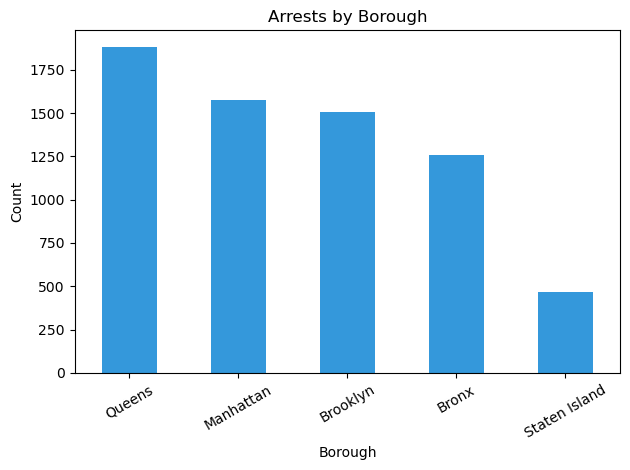

In [50]:
# Plot arrests by borough
# Counting how many arrests happened in each borough
borough_counts = df['Borough'].value_counts()

# Using a bar chart to compare the volume of arrests across the city
borough_counts.plot(kind='bar', color='#3498DB')
plt.title("Arrests by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.xticks(rotation=30)

# Adjusting layout so the titles and labels fit perfectly in the final export
plt.tight_layout()
plt.show()

## Data Visualization

Even though we pulled data for all of NYC, Queens is clearly the hotspot in January 2025. It’s interesting that the numbers in Staten Island are so much lower (under 500), which might be due to lower population density or different patrol levels.

In [51]:
# Counted frequency of each category in gender
df["Gender"].value_counts()

Gender
Male      5629
Female    1060
Name: count, dtype: int64

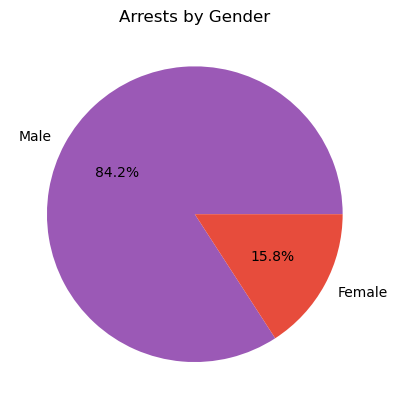

In [52]:
# Count arrests by gender
gender_counts = df['Gender'].value_counts()
# Created a pie chart 
plt.pie(gender_counts, labels = gender_counts.index, autopct = '%1.1f%%', colors = {'#E74C3C', '#9B59B6'})
plt.title('Arrests by Gender')
plt.show()

In [53]:
# Create a new column for day of week
# Analysis: Arrests by Day of Week
# Created new column called Day_of_Week in the DataFrame
df["Day_of_Week"] = df["Arrest_Date"].dt.day_name()
# Sorted count of arrests for each day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_counts = df["Day_of_Week"].value_counts().reindex(day_order)
day_counts

Day_of_Week
Monday        773
Tuesday      1095
Wednesday    1237
Thursday     1268
Friday        955
Saturday      719
Sunday        642
Name: count, dtype: int64

This chart comparess arrests across boroughs.

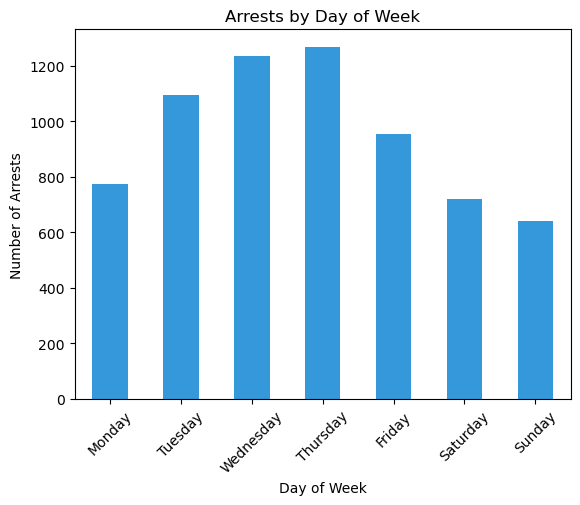

In [54]:
# Plot arrests by day of week 
day_counts.plot(kind = "bar", title = "Arrests by Day of Week", color = '#3498DB')
# Plotting the bar graph
plt.xlabel("Day of Week")
plt.ylabel("Number of Arrests")
plt.xticks(rotation = 45)
plt.show()

In [55]:
# Analysis: Number of Arrests by Age Groups
df['Age_Group'].value_counts()

Age_Group
25-44    3962
45-64    1495
18-24     889
<18       224
65+       119
Name: count, dtype: int64

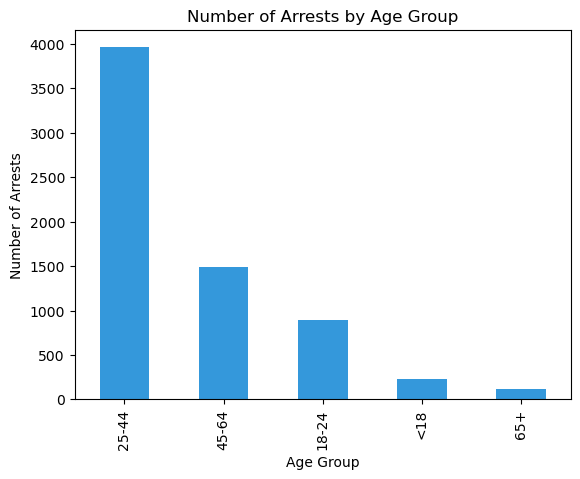

In [56]:
# Plot arrests by age group
# Plots a blue bar chart showing the number of arrests for each age group
df['Age_Group'].value_counts().plot(kind='bar', title='Number of Arrests by Age Group', color = '#3498DB')

plt.xlabel('Age Group')
plt.ylabel('Number of Arrests')
plt.show()

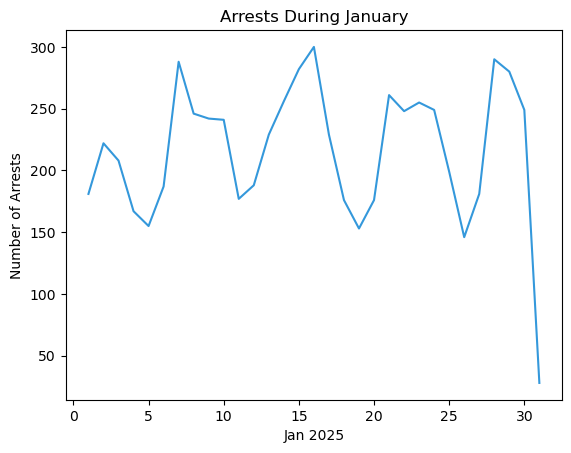

In [57]:
# Groups arrests by date 
daily_counts = df.groupby("Arrest_Date").size()
# Extracts day num from each date and plots a blue line chart showing how the number of arrests fluctuated across each day in January 2025.
daily_counts.index = daily_counts.index.day
daily_counts.plot(kind='line', title="Arrests During January", color = '#3498DB')
plt.xlabel("Jan 2025")
plt.ylabel("Number of Arrests")
plt.show()

This section comparess arrests by gender.

In [58]:
# Create a simple violent/non-violent category
# Analysis: Violent VS Non-Violent
df['Violent_Offense'].value_counts()

Violent_Offense
False    5759
True      930
Name: count, dtype: int64

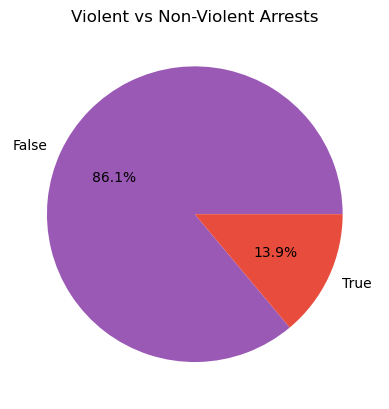

In [59]:
# Create a simple violent/non-violent category
subscribers = df['Violent_Offense'].value_counts()

plt.pie(subscribers, labels=subscribers.index, autopct='%1.1f%%', colors = {'#E74C3C', '#9B59B6'})
plt.title('Violent vs Non-Violent Arrests')
plt.show()

In [60]:
# Analysis: Top 10 Offense Categories
df['Offense_Category'].value_counts().head(10)

Offense_Category
DANGEROUS DRUGS                   721
PETIT LARCENY                     712
ASSAULT 3 & RELATED OFFENSES      647
FELONY ASSAULT                    586
MISCELLANEOUS PENAL LAW           562
ROBBERY                           344
DANGEROUS WEAPONS                 339
GRAND LARCENY                     321
BURGLARY                          270
CRIMINAL MISCHIEF & RELATED OF    233
Name: count, dtype: int64

These chartss helped show patterns in the dataet.

This chart comparess arrests across age groups.

The 25–44 age group had the highest arrest count across most boroughs.

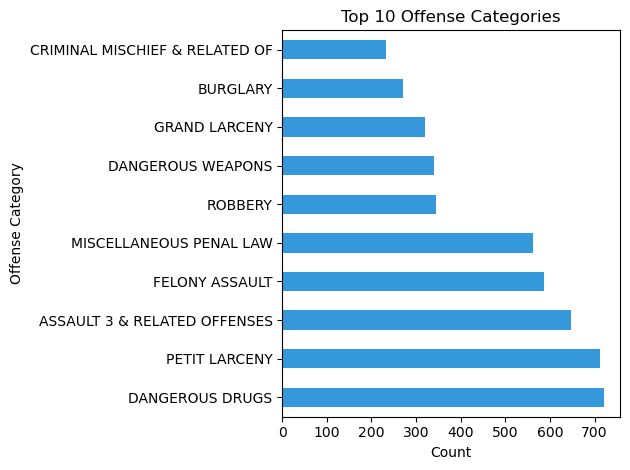

In [61]:
# Count arrests by offense type
df["Offense_Category"].value_counts().head(10).plot(kind="barh", title="Top 10 Offense Categories", color = '#3498DB')

plt.xlabel("Count")
plt.ylabel("Offense Category")
plt.tight_layout()
plt.show()

## Challenges

One challenge was working with a large API dataet. We also had to clean missing values and organize the columns before creating charts.